# Node embeddings — from proximity to node2vec

This tutorial walks through three ways to turn nodes into vectors for machine learning, in increasing order of sophistication:

1. **Hand-crafted features** — degree, centrality, clustering, and other classical network statistics
2. **Graphlet (orbit) counts** — counting where a node sits inside small subgraph patterns
3. **node2vec embeddings** — vectors *learned* by a Skip-gram model trained on biased random walks

We end with a benchmark on Zachary's Karate Club: predicting which faction each member joins after the club splits. Before we get there, we build intuition on a tiny graph: **what does it actually mean for two nodes to be similar?**


In [1]:
from netsci_utils import *
set_seeds()
%matplotlib inline

In [2]:
import torch
import random
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch_geometric.nn.models import Node2Vec

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEPOCH = 200  # epochs for node2vec training

## 1. What does "similar" mean in a graph?

Before any algorithm runs, we have to decide **what kind of similarity we want the embeddings to preserve**. The same pair of nodes can be similar or not, depending on the question we ask:

- *Are they directly connected?* → **first-order** similarity
- *Do they share neighbours?* → **second-order** similarity (friend-of-friend)
- *Is one reachable from the other in a few steps?* → **higher-order** similarity

The choice of similarity is the most consequential design decision in any embedding method — it determines which downstream tasks the embeddings will be good at.

We illustrate the three orders on the same tiny graph used in the lecture.


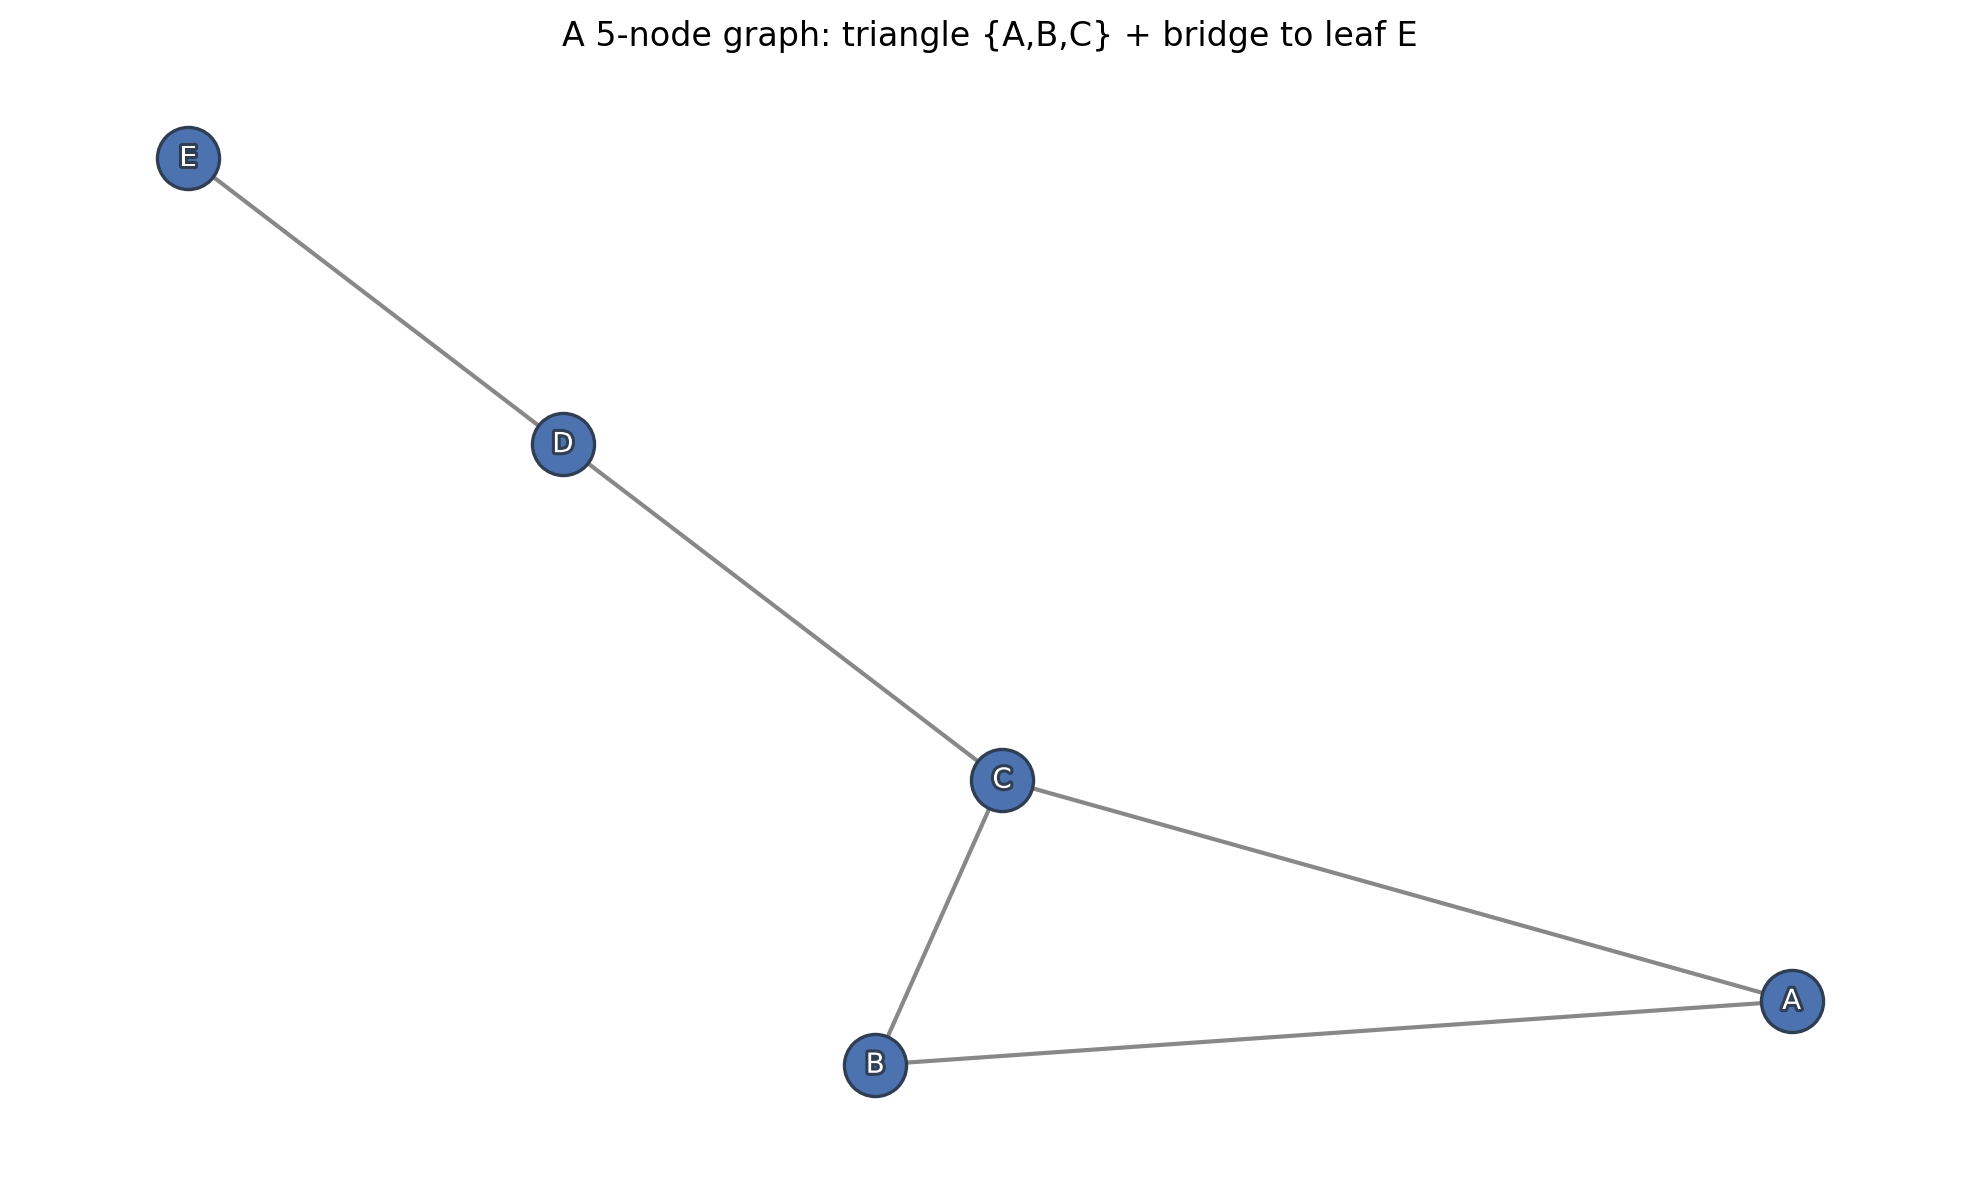

In [3]:
toy = nx.Graph()
toy.add_edges_from([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"), ("D", "E")])

plot_graph(toy, title="A 5-node graph: triangle {A,B,C} + bridge to leaf E",
           with_labels=True)

The graph has a triangle on `{A, B, C}` (all pairwise connected), a bridge from `C` to `D`, and a leaf `E` attached to `D`. Node `C` is the central hub.

We now compute three proximity matrices and watch how each pair of nodes is judged differently.


In [4]:
def show_matrix(M, title, order):
    print(title)
    print("    " + "  ".join(f"{c:>2}" for c in order))
    for i, label in enumerate(order):
        print(f"{label:<3} " + "  ".join(f"{int(x):>2}" for x in M[i]))
    print()

order = ["A", "B", "C", "D", "E"]
A = nx.to_numpy_array(toy, nodelist=order, dtype=int)
show_matrix(A, "First-order proximity (adjacency matrix A):", order)

First-order proximity (adjacency matrix A):
     A   B   C   D   E
A    0   1   1   0   0
B    1   0   1   0   0
C    1   1   0   1   0
D    0   0   1   0   1
E    0   0   0   1   0



**Reading the matrix.** A `1` at position `(u, v)` means "there is a direct edge between `u` and `v`". Under first-order similarity, only direct neighbours are similar.

- `(A, B) = 1`, `(A, C) = 1`, `(B, C) = 1` — the triangle
- `(A, D) = 0`, `(A, E) = 0` — not adjacent

Notice that `A`–`D` and `A`–`E` get the same score (`0`), even though `A` is much closer to `D` (one hop away through `C`) than to `E`. **First-order proximity is too coarse for many tasks.**


In [5]:
A2 = A @ A
show_matrix(A2, "Second-order proximity (A^2 = number of length-2 paths):", order)

Second-order proximity (A^2 = number of length-2 paths):
     A   B   C   D   E
A    2   1   1   1   0
B    1   2   1   1   0
C    1   1   3   0   1
D    1   1   0   2   0
E    0   0   1   0   1



**Reading $A^2$.** Entry $(A^2)_{uv}$ counts the number of length-2 paths between `u` and `v` — i.e., how many common neighbours they share.

- `(A, D) = 1` — `A` and `D` share neighbour `C`. They were unrelated under first-order proximity but **are** related under second-order.
- `(A, E) = 0` — still no common neighbour.

Second-order proximity captures **friend-of-friend** relationships: nodes that are close in the network without being directly connected.


In [6]:
A3 = A @ A @ A
show_matrix(A3, "Third-order proximity (A^3 = number of length-3 paths):", order)

Third-order proximity (A^3 = number of length-3 paths):
     A   B   C   D   E
A    2   3   4   1   1
B    3   2   4   1   1
C    4   4   2   4   0
D    1   1   4   0   2
E    1   1   0   2   0



**Reading $A^3$.** Entry $(A^3)_{uv}$ counts the number of length-3 paths between `u` and `v`.

- `(A, E) = 1` — there is a length-3 path `A → C → D → E`. The leaf is finally reachable.

**The takeaway.** The same pair `(A, E)` has similarity `0`, `0`, `1` under the three orders. **Different similarity choices lead to different embeddings**, each good for a different purpose. node2vec — the protagonist of this notebook — captures a particular **multi-order** notion of similarity through random walks.


## 2. The classification task — Zachary's Karate Club

We move from intuition to a concrete benchmark. **Zachary's Karate Club** is a small social network: 34 members, 78 friendship ties. After an internal dispute, the club split into two factions — one around the instructor (Mr. Hi) and one around the officer.

**Question:** can we predict each member's faction using only the structure of the friendship network — without knowing the individual story behind the split?

This is a node classification task: each node is one member, the input is the graph, the label is the faction.


In [7]:
G = nx.karate_club_graph()
nodes = list(G.nodes())
label_map = {"Mr. Hi": 0, "Officer": 1}
labels = np.array([label_map[G.nodes[v]["club"]] for v in nodes])

print_network_stats(G)
print(f"\nFaction sizes: Mr. Hi = {(labels == 0).sum()}, Officer = {(labels == 1).sum()}")

Nodes          : 34
Edges          : 78
Density        : 0.139037
Average degree : 4.5882
Avg clustering : 0.5706
Diameter       : 5

Faction sizes: Mr. Hi = 17, Officer = 17


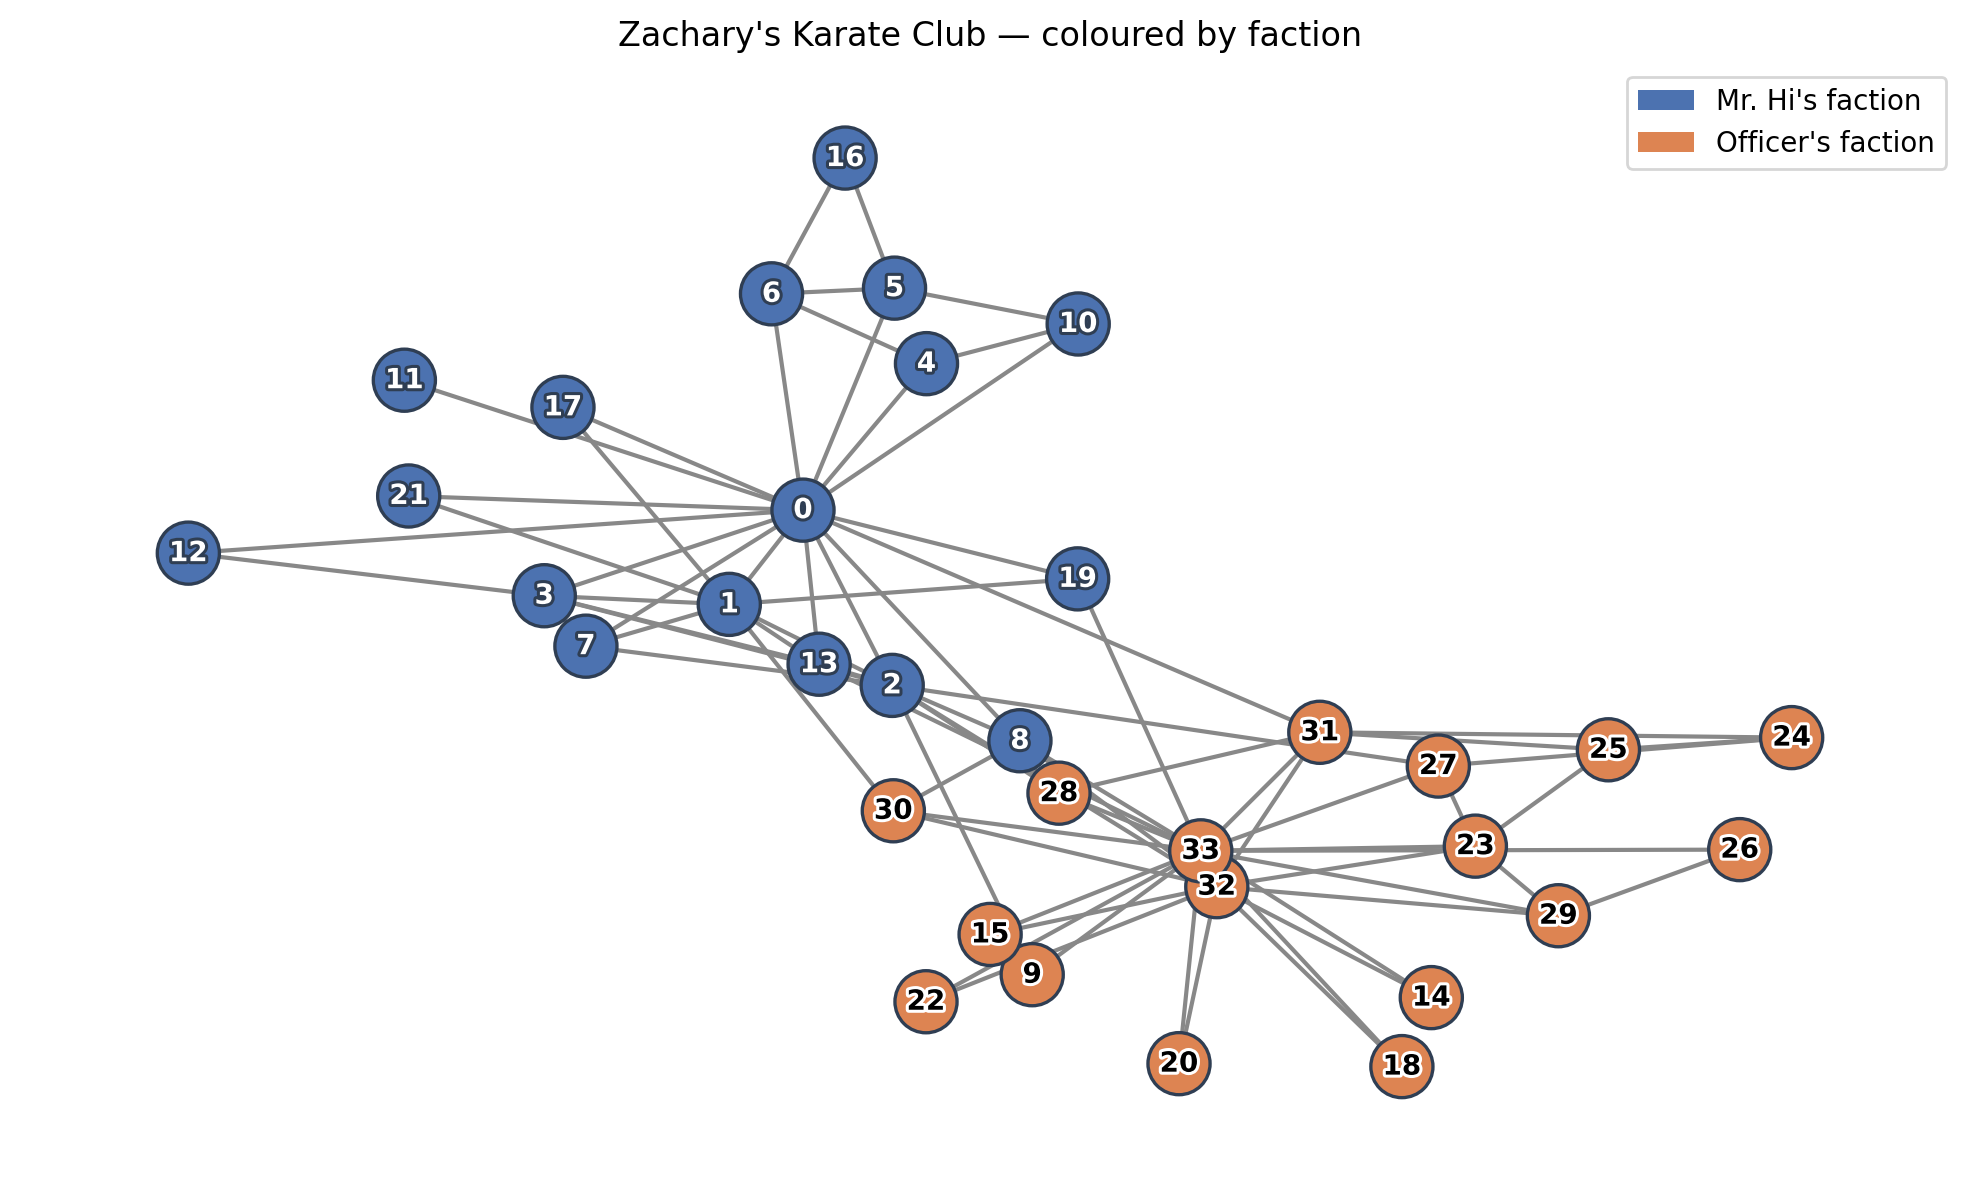

In [8]:
node_colors = colors_from_node_attribute(G, "club", KARATE_CLUB_COLORS)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
draw_graph(G, ax=ax, node_color=node_colors, font_weight="bold", seed=RANDOM_SEED)

ax.legend(
    handles=[
        Patch(facecolor=KARATE_CLUB_COLORS["Mr. Hi"], label="Mr. Hi's faction"),
        Patch(facecolor=KARATE_CLUB_COLORS["Officer"], label="Officer's faction"),
    ],
    loc="upper right",
)
ax.set_title("Zachary's Karate Club — coloured by faction")
plt.tight_layout()
plt.show()

## 3. Three approaches to node features

We will represent each node as a feature vector and feed those vectors into a simple **logistic-regression** classifier. Three families of features, in increasing order of sophistication:

| Approach                | Captures                          | How features are built              |
| ----------------------- | --------------------------------- | ----------------------------------- |
| Hand-crafted metrics    | summary statistics about the node | one number per metric (degree, …)   |
| Graphlet (orbit) counts | local subgraph structure          | counts of small subgraph patterns   |
| node2vec                | random-walk neighbourhood         | learned $d$-dimensional vector      |

For each approach, we evaluate with **5-fold stratified cross-validation**: split the 34 members into 5 groups of similar size, train on 4 groups and test on the 5th, repeat 5 times, average the accuracy.


In [9]:
def cv_score(features, labels, n_splits=5):
    """5-fold stratified CV accuracy with a logistic-regression classifier."""
    X = StandardScaler().fit_transform(features)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, test_idx in skf.split(X, labels):
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
        clf.fit(X[train_idx], labels[train_idx])
        scores.append(accuracy_score(labels[test_idx], clf.predict(X[test_idx])))
    return float(np.mean(scores))

## 4. Method 1 — Hand-crafted network features

The classical approach: compute well-known network statistics for each node and stack them into a feature vector. We use eight metrics that capture different facets of a node's role.

| Feature                | What it measures                                |
| ---------------------- | ----------------------------------------------- |
| Degree                 | Number of direct connections                    |
| Clustering coefficient | How interconnected your neighbours are          |
| Triangles              | How many triangles you sit in                   |
| Betweenness centrality | How often you lie on shortest paths             |
| Closeness centrality   | How quickly you can reach the rest of the graph |
| Eigenvector centrality | How well-connected your neighbours are          |
| Eccentricity           | Distance to the furthest node                   |
| Avg. neighbour degree  | Mean degree of your neighbours                  |

Each member becomes an 8-dimensional vector — every dimension chosen by **us**, not learned from the graph.


In [10]:
def extract_traditional_features(G):
    degree = dict(G.degree())
    clustering = nx.clustering(G)
    triangles = nx.triangles(G)
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    except (nx.PowerIterationFailedConvergence, nx.NetworkXError):
        eigenvector = {n: 0.0 for n in G.nodes()}
    eccentricity = nx.eccentricity(G) if nx.is_connected(G) else {n: 0 for n in G.nodes()}

    rows = []
    for v in G.nodes():
        neigh_deg = [degree[n] for n in G.neighbors(v)]
        rows.append([
            degree[v],
            clustering[v],
            triangles[v],
            betweenness[v],
            closeness[v],
            eigenvector[v],
            eccentricity[v],
            float(np.mean(neigh_deg)) if neigh_deg else 0.0,
        ])
    return np.array(rows)


X_traditional = extract_traditional_features(G)
traditional_score = cv_score(X_traditional, labels)

print(f"Hand-crafted feature matrix: {X_traditional.shape}")
print(f"5-fold CV accuracy: {traditional_score:.4f}")

Hand-crafted feature matrix: (34, 8)
5-fold CV accuracy: 0.8238


**What just happened.** Each member is an 8-dimensional vector of pre-computed statistics; the classifier finds a linear boundary in that 8-D space. Accuracy is around 0.80 — a respectable baseline, but with a clear ceiling: the features were chosen by us, so the classifier can only do as well as our intuition allows.


## 5. Method 2 — Graphlet (orbit) counts

A more refined approach: instead of summary statistics, count how many times each node appears in each **structural position** within small subgraphs.

A **graphlet** is a small connected subgraph (size 2 to 5 here). Within a graphlet, an **orbit** is a set of equivalent positions — for example, in a 3-node path, the two endpoints share an orbit (they are interchangeable under the graph's symmetries) while the middle node forms its own orbit.

For each node we count how often it appears in each orbit across all small subgraphs of the network. The result is a much richer, more local description than 8 hand-crafted statistics.

The implementation has three parts:

1. **Enumerate templates** — list every connected graphlet of sizes 2–5 (NetworkX provides them via `nx.graph_atlas_g()`)
2. **Pre-compute orbits and pruning info** — for each template, find its orbits (positions equivalent under the template's automorphisms) and a Weisfeiler–Lehman hash that lets us discard non-matching subgraphs quickly
3. **Sweep all node subsets in `G`** — for each subset whose induced subgraph is connected, identify which template it matches and increment the orbit-count for each node in the corresponding position


In [11]:
import itertools
from networkx.algorithms.isomorphism import GraphMatcher
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash


def get_connected_templates(max_k=5):
    """Return a dict {k: [templates]} of all connected graphlets of size 2..max_k."""
    atlas = nx.graph_atlas_g()
    templates = {k: [] for k in range(2, max_k + 1)}
    for H in atlas:
        n = H.number_of_nodes()
        if 2 <= n <= max_k and nx.is_connected(H):
            templates[n].append(nx.convert_node_labels_to_integers(H))
    return templates


def template_orbits(T):
    """Return the orbits of template T: groups of nodes that are interchangeable under T's automorphisms."""
    autos = list(GraphMatcher(T, T).isomorphisms_iter())
    unassigned = set(T.nodes())
    orbits = []
    while unassigned:
        seed_node = unassigned.pop()
        orbit = {seed_node}
        changed = True
        while changed:
            changed = False
            for auto in autos:
                for u in list(orbit):
                    v = auto[u]
                    if v not in orbit:
                        orbit.add(v)
                        changed = True
        orbits.append(sorted(orbit))
        unassigned -= orbit
    return orbits


def group_by_wl_and_degree(templates):
    """Pre-compute hashes and orbits for fast subgraph matching."""
    wl_groups, deg_groups, orbits_map = {}, {}, {}
    for k, tlist in templates.items():
        wl_map, deg_map, orbits = {}, {}, []
        for tidx, T in enumerate(tlist):
            wl_map.setdefault(weisfeiler_lehman_graph_hash(T, iterations=2), []).append(tidx)
            deg_map.setdefault(tuple(sorted(dict(T.degree()).values())), []).append(tidx)
            orbits.append(template_orbits(T))
        wl_groups[k], deg_groups[k], orbits_map[k] = wl_map, deg_map, orbits
    return wl_groups, deg_groups, orbits_map


def build_orbit_features(G, nodes, templates, wl_groups, deg_groups, orbits_map, max_k=5):
    """Count orbit occurrences for every node by sweeping all connected k-subsets."""
    n = len(nodes)
    idx_of = {v: i for i, v in enumerate(nodes)}

    feature_idx, feature_names, col = {}, [], 0
    for k, tlist in templates.items():
        for tidx, orbits in enumerate(orbits_map[k]):
            for oidx in range(len(orbits)):
                feature_idx[(k, tidx, oidx)] = col
                feature_names.append(f"g{k}_t{tidx}_o{oidx}")
                col += 1

    X = np.zeros((n, col), dtype=int)

    for k in range(2, max_k + 1):
        for combo in itertools.combinations(nodes, k):
            H = G.subgraph(combo)
            if not nx.is_connected(H):
                continue
            seq = tuple(sorted(dict(H.degree()).values()))
            if seq not in deg_groups[k]:
                continue
            h = weisfeiler_lehman_graph_hash(H, iterations=2)
            if h not in wl_groups[k]:
                continue
            for tidx in wl_groups[k][h]:
                if tidx not in deg_groups[k][seq]:
                    continue
                T = templates[k][tidx]
                GM = GraphMatcher(H, T)
                if not GM.is_isomorphic():
                    continue
                inv_map = {t: hh for hh, t in GM.mapping.items()}
                for oidx, orbit in enumerate(orbits_map[k][tidx]):
                    c = feature_idx[(k, tidx, oidx)]
                    for tn in orbit:
                        X[idx_of[inv_map[tn]], c] += 1
                break
    return X, feature_names

In [12]:
templates = get_connected_templates(max_k=5)
wl_groups, deg_groups, orbits_map = group_by_wl_and_degree(templates)
X_graphlets, _ = build_orbit_features(G, nodes, templates, wl_groups, deg_groups, orbits_map, max_k=5)

graphlet_score = cv_score(X_graphlets, labels)

print(f"Graphlet feature matrix: {X_graphlets.shape}")
print(f"5-fold CV accuracy: {graphlet_score:.4f}")

Graphlet feature matrix: (34, 73)
5-fold CV accuracy: 0.8571


**What just happened.** Each member is now described by a much higher-dimensional feature vector — every coordinate is a count like *"how many length-3 paths am I the middle of?"* or *"how many 4-cliques do I appear in?"*. Accuracy improves over the hand-crafted baseline because **the local subgraph structure carries community information** that summary statistics miss.

But we still chose the size of the graphlets. We didn't tell the algorithm which positions matter for predicting factions — we just listed them all. The next method goes one step further: it **learns** the features.


## 6. Method 3 — node2vec

node2vec **learns** node vectors instead of computing them. The recipe — straight from the lecture:

1. Run many **biased random walks** from each node
2. Treat each walk as a "sentence" and each node as a "word"
3. Train **Skip-gram with negative sampling**: for every (target, context) pair seen in a walk, push the two vectors closer; for a few random non-context nodes, push them apart

The bias is controlled by two parameters that change **what the walks see**:

- **Return parameter $p$** — chance of stepping back to the previous node
  - $p < 1$: walks revisit (stay local)
  - $p > 1$: walks avoid backtracking (explore outward)

- **In-out parameter $q$** — direction of exploration
  - $q < 1$: walks venture outward (DFS-like → captures **homophily / communities**)
  - $q > 1$: walks stay near the source (BFS-like → captures **structural equivalence / roles**)

Setting $p = q = 1$ recovers DeepWalk's plain uniform walks.


In [13]:
def train_node2vec(edge_index, embedding_dim=8, walk_length=8, context_size=4,
                   walks_per_node=20, negative_samples=2, p=1.0, q=1.0,
                   epochs=NEPOCH, verbose=False):
    """Train a node2vec model and return the per-node embedding matrix."""
    model = Node2Vec(
        edge_index, embedding_dim=embedding_dim, walk_length=walk_length,
        context_size=context_size, walks_per_node=walks_per_node,
        num_negative_samples=negative_samples, p=p, q=q, sparse=True,
    ).to(DEVICE)

    loader = model.loader(batch_size=128, shuffle=True)
    optimizer = torch.optim.SparseAdam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(DEVICE), neg_rw.to(DEVICE))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if verbose and (epoch == 1 or epoch % 50 == 0):
            print(f"  epoch {epoch:3d}/{epochs}  loss={total_loss:.4f}")

    model.eval()
    with torch.no_grad():
        return model().cpu().numpy()


edge_index = torch.tensor(list(G.edges()), dtype=torch.long).t().contiguous()

### A first run — DeepWalk equivalent ($p = q = 1$)

Before sweeping the parameters, we run node2vec at the **DeepWalk default** ($p = q = 1$, plain uniform random walks). This is our minimum-tuning baseline.


In [14]:
print("Training node2vec with p = q = 1 (the DeepWalk setting)...")
emb_baseline = train_node2vec(edge_index, p=1.0, q=1.0, verbose=True)

baseline_score = cv_score(emb_baseline, labels)
print(f"\nDeepWalk-style 5-fold CV accuracy: {baseline_score:.4f}")

Training node2vec with p = q = 1 (the DeepWalk setting)...
  epoch   1/200  loss=1.8157
  epoch  50/200  loss=1.0969
  epoch 100/200  loss=0.9144
  epoch 150/200  loss=0.8523
  epoch 200/200  loss=0.8298

DeepWalk-style 5-fold CV accuracy: 0.8857


Already with no $(p, q)$ tuning, node2vec lands close to or above the hand-crafted baseline. The next step: do the knobs matter?

### Sweeping $(p, q)$

We try a $5 \times 5$ grid of values for each parameter and record the CV accuracy. This shows how the **walk strategy** alone changes downstream performance — the encoder, the decoder (dot product), and the training objective are identical across all 25 runs.


In [15]:
p_values = [0.25, 0.5, 1.0, 2.0, 4.0]
q_values = [0.25, 0.5, 1.0, 2.0, 4.0]

pq_scores = np.zeros((len(p_values), len(q_values)))
best_score, best_params, best_emb = 0.0, None, None

for i, p in enumerate(p_values):
    for j, q in enumerate(q_values):
        emb = train_node2vec(edge_index, p=p, q=q)
        score = cv_score(emb, labels)
        pq_scores[i, j] = score
        if score > best_score:
            best_score, best_params, best_emb = score, (p, q), emb
        print(f"  p={p:>4}  q={q:>4}  →  CV accuracy = {score:.4f}")

print(f"\nBest (p, q) = {best_params}  with CV accuracy {best_score:.4f}")

  p=0.25  q=0.25  →  CV accuracy = 0.7952
  p=0.25  q= 0.5  →  CV accuracy = 0.8190
  p=0.25  q= 1.0  →  CV accuracy = 0.8238
  p=0.25  q= 2.0  →  CV accuracy = 0.8000
  p=0.25  q= 4.0  →  CV accuracy = 0.7048
  p= 0.5  q=0.25  →  CV accuracy = 0.7381
  p= 0.5  q= 0.5  →  CV accuracy = 0.8000
  p= 0.5  q= 1.0  →  CV accuracy = 0.7381
  p= 0.5  q= 2.0  →  CV accuracy = 0.8524
  p= 0.5  q= 4.0  →  CV accuracy = 0.8571
  p= 1.0  q=0.25  →  CV accuracy = 0.8286
  p= 1.0  q= 0.5  →  CV accuracy = 0.8476
  p= 1.0  q= 1.0  →  CV accuracy = 0.8524
  p= 1.0  q= 2.0  →  CV accuracy = 0.8238
  p= 1.0  q= 4.0  →  CV accuracy = 0.7667
  p= 2.0  q=0.25  →  CV accuracy = 0.9095
  p= 2.0  q= 0.5  →  CV accuracy = 0.7714
  p= 2.0  q= 1.0  →  CV accuracy = 0.7667
  p= 2.0  q= 2.0  →  CV accuracy = 0.7333
  p= 2.0  q= 4.0  →  CV accuracy = 0.8190
  p= 4.0  q=0.25  →  CV accuracy = 0.7952
  p= 4.0  q= 0.5  →  CV accuracy = 0.7381
  p= 4.0  q= 1.0  →  CV accuracy = 0.8571
  p= 4.0  q= 2.0  →  CV accuracy =

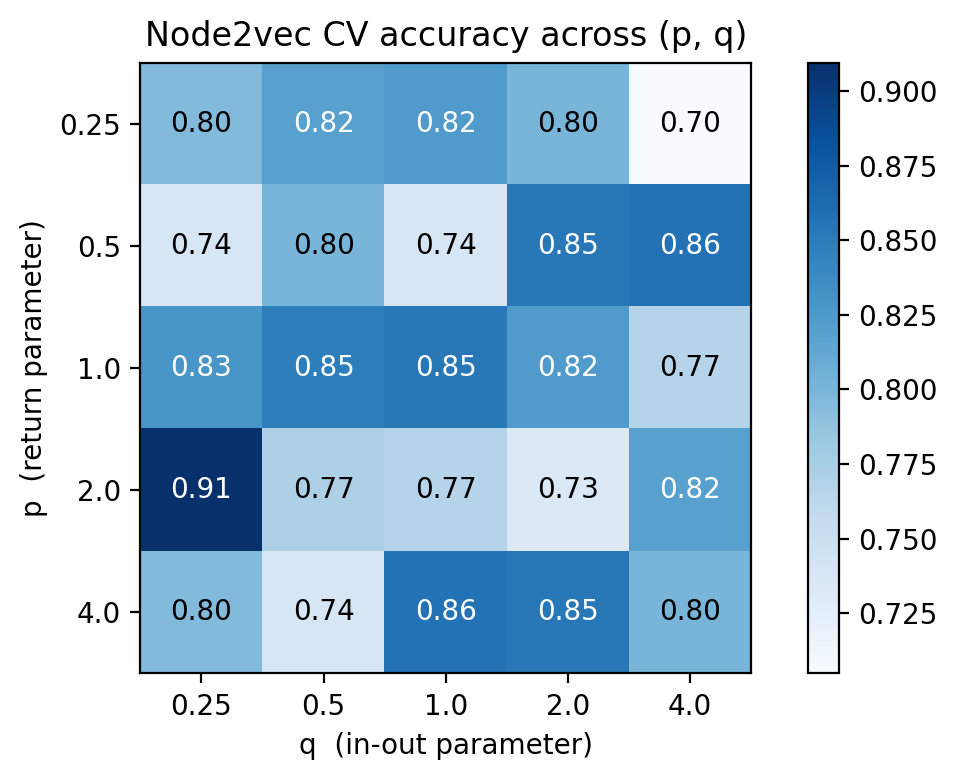

In [16]:
fig, ax = plot_heatmap(
    pq_scores,
    x_labels=q_values,
    y_labels=p_values,
    title="Node2vec CV accuracy across (p, q)",
    figure_size=FIGURE_SIZE_SMALL,
)
ax.set_xlabel("q  (in-out parameter)")
ax.set_ylabel("p  (return parameter)")
plt.show()

**Reading the heatmap.**

The **bottom-left corner** ($p, q$ both small) tends to do best on this task. Small $q$ encourages **outward, DFS-like** exploration — exactly the regime that captures **homophily / community structure**. And Karate Club is a community-detection task in disguise: each faction *is* a community.

The **top-right corner** ($p, q$ both large) penalises both backtracking and outward moves, leaving the walks somewhere in between. It does worse here because the task rewards the community signal, not a role signal.

Same algorithm, same data — different walk strategy, different structure surfaced. This is exactly the lesson from the lecture.


## 7. The three methods side by side


In [17]:
methods = ["Hand-crafted", "Graphlets", "node2vec (best p,q)"]
accuracies = [traditional_score, graphlet_score, best_score]

print(f"{'Method':<22} {'CV accuracy':<12}")
print("-" * 36)
for m, acc in zip(methods, accuracies):
    print(f"{m:<22} {acc:.4f}")

Method                 CV accuracy 
------------------------------------
Hand-crafted           0.8238
Graphlets              0.8571
node2vec (best p,q)    0.9095


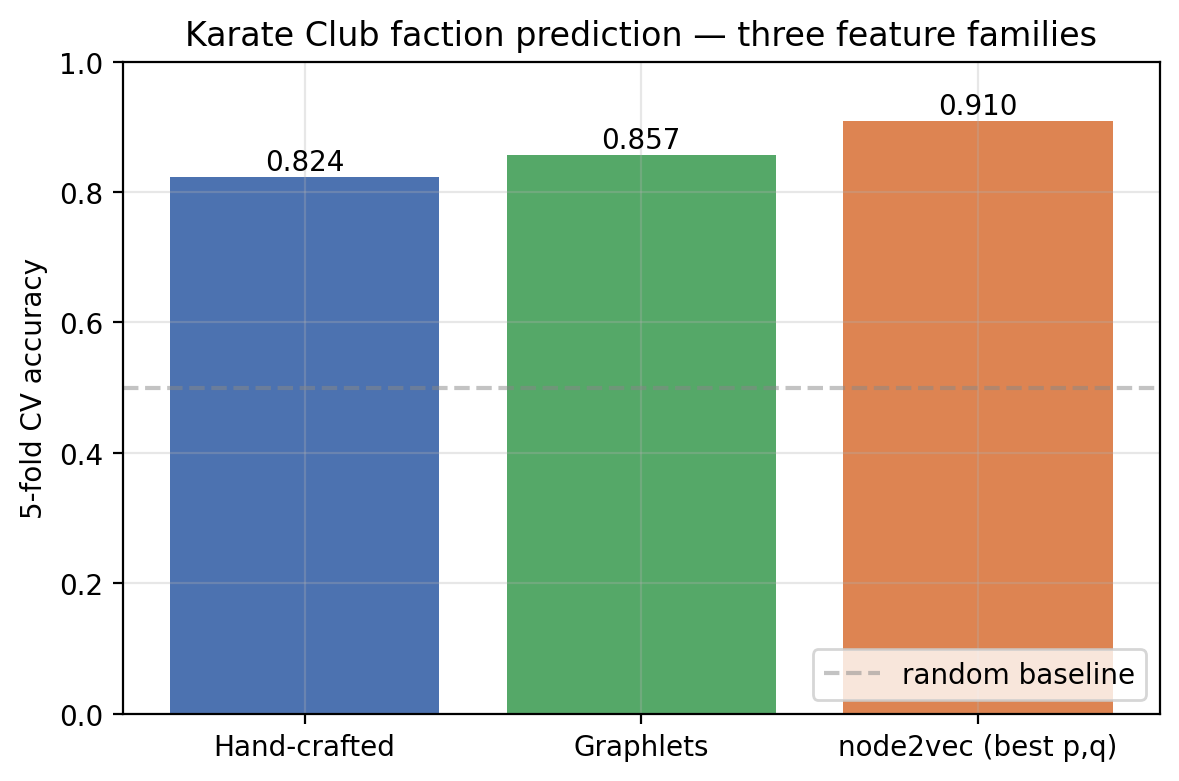

In [18]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
bars = ax.bar(
    methods, accuracies,
    color=[CATEGORY_PALETTE["blue"], CATEGORY_PALETTE["green"], CATEGORY_PALETTE["orange"]],
)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, linestyle="--", color=EDGE_COLOR, alpha=0.5, label="random baseline")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Karate Club faction prediction — three feature families")
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", fontsize=10)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Summary

We saw three ways to turn nodes into vectors, evaluated on the same task:

1. **Hand-crafted features** — interpretable but limited. We chose the eight metrics; the classifier can only do as well as our choice allows.
2. **Graphlet counts** — richer local structure, no human pick-and-choose beyond the graphlet size. Improves over the baseline.
3. **node2vec** — embeddings emerge from the graph itself, with no need to design features. Even at the DeepWalk setting ($p = q = 1$) it competes with the engineered features, and after a quick $(p, q)$ search it wins clearly on this task.

**Why node2vec wins on Karate Club.** The task asks "which community does this node belong to?". With low $q$, walks wander outward through dense regions, so nodes in the same community co-occur often in walks and end up close in vector space. The encoder–decoder framework from the lecture is doing exactly what we asked of it:

- the **target similarity** is "in the same community"
- the **decoder** is the dot product
- training tunes the vectors to make graph-similarity and vector-similarity agree

**Limitations** (also covered in the lecture):

- node2vec is **transductive** — a new member joining the club requires retraining
- Only the **graph structure** is used — no node attributes
- No edge types or weights are leveraged

Graph Neural Networks address all three. That is the next chapter.
